In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

In [13]:
df = pd.read_csv('Titanic-Dataset.csv')
print("First 5 rows of the dataset:")
print(df.head())
print(f"\nDataset Shape : {df.shape}")
print(f"\nMissing value : \n{df.isnull().sum()}")


First 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

In [14]:
print("\nSurvival rate by gender:")
print(df.groupby('Sex')['Survived'].mean())

print("\nSurvival rate by passenger class:")
print(df.groupby('Pclass')['Survived'].mean())


Survival rate by gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [15]:
df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert 'Sex' column to 0 (male) and 1 (female) - GUARANTEED TO WORK!
# NEW (foolproof):
# Convert to string first (handles any dtype), then check if it's 'female'
df['Sex'] = (df['Sex'].astype(str).str.lower() == 'female').astype(int)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print(f"\nData after preprocessing:\n{df.head()}")
print(f"\nNo missing values left:\n{df.isnull().sum()}")


Data after preprocessing:
   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  \
0            1         0       3    0  22.0      1      0   7.2500   
1            2         1       1    1  38.0      1      0  71.2833   
2            3         1       3    1  26.0      0      0   7.9250   
3            4         1       1    1  35.0      1      0  53.1000   
4            5         0       3    0  35.0      0      0   8.0500   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  

No missing values left:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64


C:\Users\mhuza\AppData\Local\Temp\ipykernel_12604\2693561728.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\mhuza\AppData\Local\Temp\ipykernel_12604\2693561728.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [16]:
x=df.drop('Survived', axis=1)
y = df['Survived']

print(f"\nFeature: {x.columns.tolist()}")



Feature: ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 712
Test samples: 179


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

In [21]:
print("\n" + "="*50)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy : {accuracy_score(y_test, y_pred_log):.4f}")
print(confusion_matrix(y_test, y_pred_log))

print("\n" + "="*50)
print("RANDOM FOREST MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=['Died', 'Survived']))

      


LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy : 0.8045
[[97 13]
 [22 47]]

RANDOM FOREST MODEL PERFORMANCE
Accuracy : 0.8156

Confusion Matrix:
[[98 12]
 [21 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179

              precision    recall  f1-score   support

        Died       0.82      0.89      0.86       110
    Survived       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179




Feature Importance
       Feature  Importance
2          Sex    0.263977
6         Fare    0.189397
0  PassengerId    0.186698
3          Age    0.166163
1       Pclass    0.089512
4        SibSp    0.041744
5        Parch    0.030951
8   Embarked_S    0.021665
7   Embarked_Q    0.009894


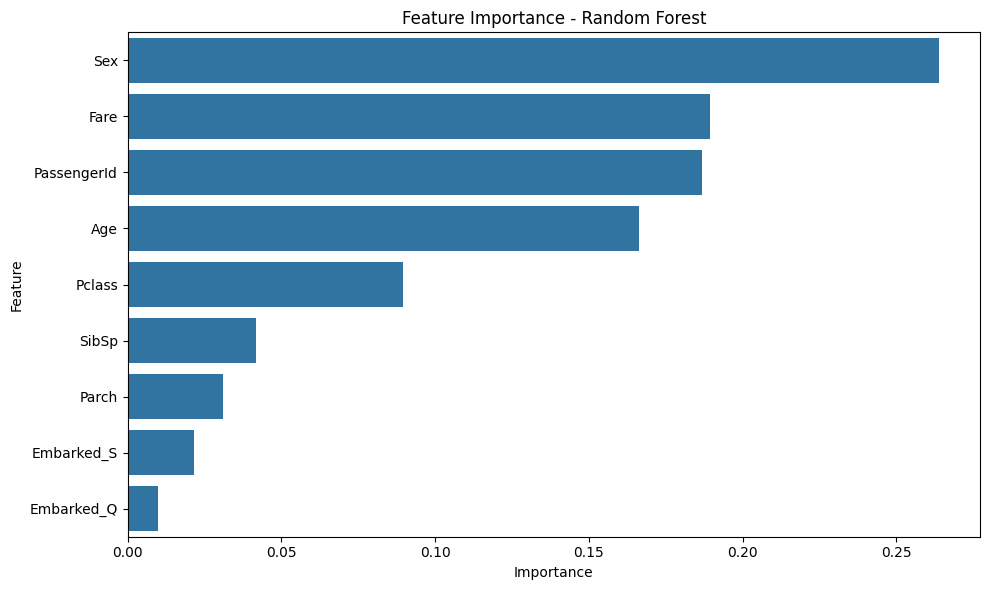

In [23]:
importance_df = pd.DataFrame({
    'Feature' : x.columns,
    'Importance' : rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance")
print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [24]:
os.makedirs('models', exist_ok=True)
joblib.dump(rf_model, 'models/titanic_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
metadata = {
    'feature_names' : x.columns.tolist(),
    'target_names' : ['Died', 'Survived'],
}

joblib.dump(metadata, 'models/metadata.pkl')
print("\nRandom Forest model saved to 'models/titanic_model.pkl'")
print("Metadata saved to 'models/metadata.pkl'")


Random Forest model saved to 'models/titanic_model.pkl'
Metadata saved to 'models/metadata.pkl'
